# Week 5 — Day 3: Hands-On Lab
## Dimensionality Reduction with PCA — Insurance Dataset

**Objective:**  
I apply Principal Component Analysis to the insurance dataset.  
My goals are to understand how much information each component carries,  
choose a component count that retains ~95% of the variance,  
and visualize the data in 2D.

**Dataset:** `insurance.csv` — 1,338 records, 7 original columns  
**After encoding:** 9 numeric features  
**Method:** PCA with StandardScaler (sklearn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

---
## Load & Prepare Data

In [2]:
df = pd.read_csv('../../Week2/Day 1/data/insurance.csv')
print(df.shape)
df.head(3)

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


### Encoding

PCA works on numbers only.  
I encode the three categorical columns using one-hot encoding,  
dropping one category per column to avoid multicollinearity.

This expands the dataset from 7 to 9 columns:
- `sex` → `sex_male` (1 column)
- `smoker` → `smoker_yes` (1 column)
- `region` → `region_northwest`, `region_southeast`, `region_southwest` (3 columns)

In [3]:
# Save smoker column for visualization before encoding
smoker_label = df['smoker'].map({'yes': 1, 'no': 0})

# Encode categorical columns
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

print("Features after encoding:")
print(df_encoded.columns.tolist())
print(f"\nShape: {df_encoded.shape}")

Features after encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Shape: (1338, 9)


---
## Step 1: Scale the Data

PCA is a variance-based method.  
A feature measured in thousands (charges) would dominate over a feature measured in units (children)  
purely because of its larger scale — not because it is genuinely more variable.

`StandardScaler` removes this problem by putting every feature on the same scale:  
mean = 0, standard deviation = 1.

In [4]:
X = df_encoded.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean per feature (should be ~0): {X_scaled.mean(axis=0).round(5)}")
print(f"Std per feature  (should be ~1): {X_scaled.std(axis=0).round(3)}")

Scaled data shape: (1338, 9)
Mean per feature (should be ~0): [-0. -0. -0. -0. -0.  0.  0. -0.  0.]
Std per feature  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## Step 2: Fit PCA — Plot Cumulative Explained Variance

I first fit PCA with all components (no reduction yet).  
This gives me the full picture of how variance is distributed across components,  
so I can make an informed decision about how many to keep.

In [5]:
pca_full = PCA()
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

print("Explained variance per component:")
for i, (ev, cum) in enumerate(zip(evr, cumulative)):
    marker = " ← 95% crossed" if i == np.argmax(cumulative >= 0.95) else ""
    print(f"  PC{i+1}: {ev*100:.2f}%  (cumulative: {cum*100:.2f}%){marker}")

Explained variance per component:
  PC1: 21.56%  (cumulative: 21.56%)
  PC2: 16.05%  (cumulative: 37.61%)
  PC3: 14.71%  (cumulative: 52.32%)
  PC4: 12.16%  (cumulative: 64.48%)
  PC5: 11.20%  (cumulative: 75.68%)
  PC6: 10.61%  (cumulative: 86.29%)
  PC7: 8.74%  (cumulative: 95.03%) ← 95% crossed
  PC8: 3.50%  (cumulative: 98.52%)
  PC9: 1.48%  (cumulative: 100.00%)


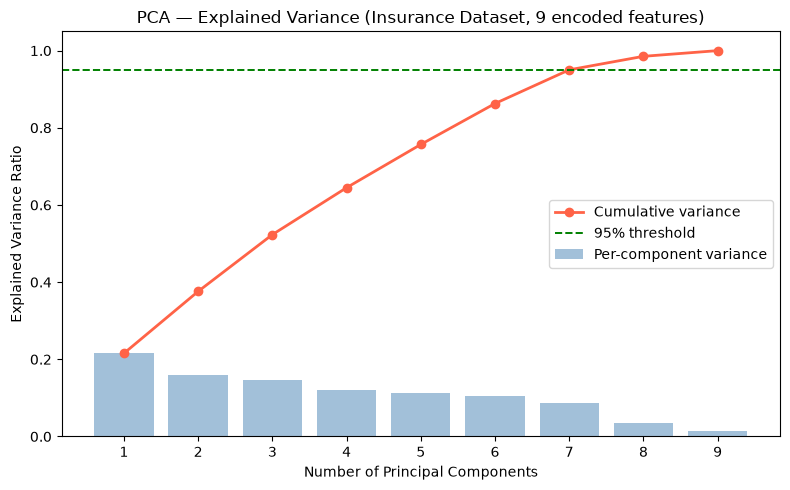

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(range(1, len(evr)+1), evr, alpha=0.5,
       color='steelblue', label='Per-component variance')
ax.plot(range(1, len(evr)+1), cumulative, 'o-',
        color='tomato', linewidth=2, label='Cumulative variance')
ax.axhline(0.95, linestyle='--', color='green',
           linewidth=1.4, label='95% threshold')

ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance (Insurance Dataset, 9 encoded features)')
ax.set_xticks(range(1, len(evr)+1))
ax.legend()
plt.tight_layout()
plt.show()

**Reading the plot:**

- Each bar shows how much variance a single component captures individually.
- The red line shows the cumulative total as components are added.
- The green dashed line marks the 95% threshold.

The variance is distributed fairly evenly across all 9 components.  
No single component dominates — this tells me that the features in the insurance dataset  
are not strongly correlated with each other, which limits how much PCA can compress them.

---
## Step 3: Choose the Number of Components

I need to find the smallest number of components that brings  
the cumulative explained variance to at least 95%.

In [7]:
n_95 = np.argmax(cumulative >= 0.95) + 1

print(f"Components needed to retain 95% variance: {n_95} (out of {X_scaled.shape[1]})")
print(f"Cumulative variance at {n_95} components:  {cumulative[n_95-1]*100:.2f}%")
print(f"Information discarded:                     {(1 - cumulative[n_95-1])*100:.2f}%")

Components needed to retain 95% variance: 7 (out of 9)
Cumulative variance at 7 components:  95.03%
Information discarded:                     4.97%


**Interpretation:**

7 components out of 9 are needed to retain 95% of the variance.

This is a relatively modest compression — from 9 features to 7.  
The reason is that the insurance dataset does not have much redundancy:  
its features (age, bmi, charges, smoker status, region) measure fairly different things  
and are not strongly correlated with each other.

In contrast, a dataset with many correlated features (e.g. 50 columns measuring  
variations of the same thing) would compress far more aggressively — perhaps from 50 to 5 components.

**Decision:** I keep **7 components** for any downstream modelling.  
For visualization, I use **2 components** and accept the lower coverage.

---
## Step 4: Reduce to 2D and Visualize

I reduce the data to 2 components for visualization.  
This is a larger compression (9 → 2), so the 37.6% variance retained is expected —  
enough to reveal the main patterns, but not a complete picture.

I color each point by smoker status, which was the dominant predictor of charges  
throughout the earlier EDA and clustering work.

In [8]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"Variance retained with 2 components: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%")

Variance retained with 2 components: 37.6%
  PC1: 21.6%
  PC2: 16.0%


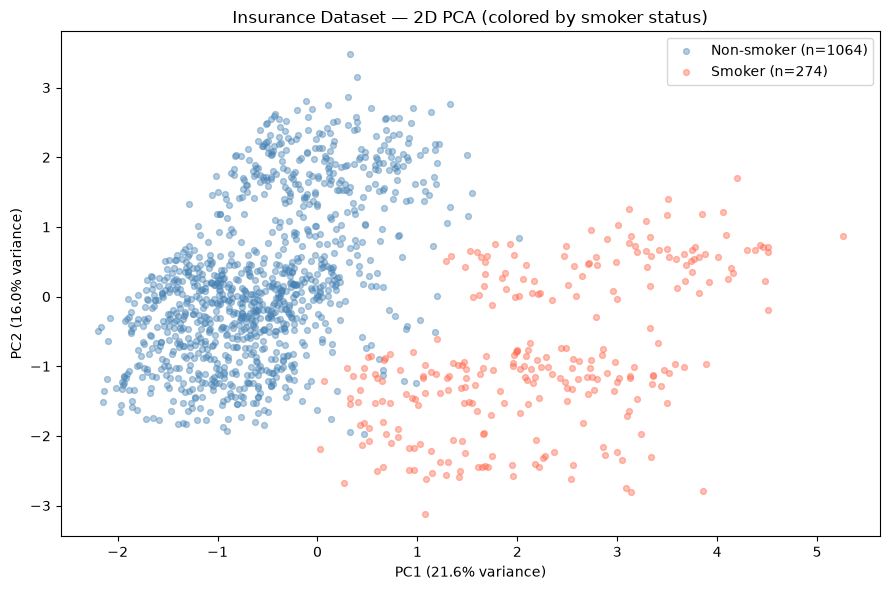

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['steelblue', 'tomato']
labels_text = [
    f'Non-smoker (n={(smoker_label==0).sum()})',
    f'Smoker (n={(smoker_label==1).sum()})'
]

for val, color, lbl in zip([0, 1], colors, labels_text):
    mask = smoker_label == val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.4, s=18, label=lbl)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Insurance Dataset — 2D PCA (colored by smoker status)')
ax.legend()
plt.tight_layout()
plt.show()

**Reading the scatter plot:**

The two groups (smokers and non-smokers) show partial separation along PC1.

This is consistent with what I found in the EDA: smoker status is the strongest single predictor of charges,  
and charges is the largest contributor to PC1 (loading = 0.654).

The separation is not clean — there is significant overlap — because PC1 captures  
several features together (charges, smoker, bmi), not just smoking alone.

PC2 captures mostly geographic variation (region_southeast and region_northwest),  
which is why points spread along that axis regardless of smoker status.

---
## Feature Loadings — What Each Component Measures

The loading table shows how much each original feature contributes to each component.

In [10]:
loadings = pd.DataFrame(
    pca_2d.components_,
    columns=df_encoded.columns,
    index=['PC1', 'PC2']
)

print("Feature loadings (contribution of each feature to each component):\n")
print(loadings.T.round(3).to_string())

print("\nTop 3 contributors to PC1:")
print(loadings.loc['PC1'].abs().sort_values(ascending=False).head(3).round(3))

print("\nTop 3 contributors to PC2:")
print(loadings.loc['PC2'].abs().sort_values(ascending=False).head(3).round(3))

Feature loadings (contribution of each feature to each component):

                    PC1    PC2
age               0.220 -0.082
bmi               0.269  0.404
children          0.055 -0.106
charges           0.654 -0.252
sex_male          0.103 -0.003
smoker_yes        0.581 -0.294
region_northwest -0.153 -0.512
region_southeast  0.260  0.632
region_southwest -0.095 -0.086

Top 3 contributors to PC1:
charges       0.654
smoker_yes    0.581
bmi           0.269
Name: PC1, dtype: float64

Top 3 contributors to PC2:
region_southeast    0.632
region_northwest    0.512
bmi                 0.404
Name: PC2, dtype: float64


**Interpretation of the components:**

| Component | Dominant features | Interpretation |
|-----------|------------------|-----------------|
| PC1 | charges (0.654), smoker_yes (0.581), bmi (0.269) | The "cost/risk" axis — points higher on PC1 are more likely to be smokers with high charges |
| PC2 | region_southeast (0.632), region_northwest (0.512), bmi (0.404) | The "geographic-BMI" axis — separates regions and body composition |

This confirms that the first two components pick up the most important patterns  
the EDA already revealed: cost driven by smoking and BMI, and geographic variation between regions.

---
## Step 5: What the Reduction Preserved — and What It Cost

**What was preserved:**

- 95% of the total variance is retained using 7 components.
- The 2-component visualization captures 37.6% — enough to see the smoker/non-smoker  
  separation that dominated the EDA.
- The main structure of the data (cost driven by smoking and BMI, regional differences)  
  is visible in the first two components.
- The loadings confirm that PC1 is interpretable as a "risk/cost" axis,  
  connecting directly to the business question.

**What was lost:**

- The 2D projection discards 62.4% of the total variance.
- The clean separation between smokers and non-smokers visible in the original feature space  
  (charges vs. smoker) is blurred in PCA space, because the components mix several features together.
- Individual feature interpretability is gone: I can no longer say  
  "bmi alone caused this point to be here" — the components are combinations, not original columns.
- The 7-component reduction loses 5% of the variance, which is acceptable for most downstream models,  
  but edge cases near cluster boundaries may shift.

**Practical takeaway:**

For the insurance dataset, PCA is more useful for **visualization** (2D scatter)  
than for **compression** (9 → 7 is a modest saving).  
If I were working with a 100-feature dataset where many features were correlated  
(e.g. medical measurements), PCA compression would be far more valuable.

---
## Summary

| Step | What I did | Result |
|------|-----------|--------|
| Encode | One-hot encoding of sex, smoker, region | 7 columns → 9 columns |
| Scale | StandardScaler (mean=0, std=1) | Ready for PCA |
| Full PCA | Fit all 9 components, compute explained variance | Variance distributed evenly |
| 95% threshold | Find minimum components to reach 95% | **7 components** needed |
| 2D reduction | Reduce to 2 components for visualization | 37.6% variance retained |
| Scatter plot | Color by smoker status | Partial separation visible on PC1 |
| Loadings | Identify top contributors per component | PC1 = cost/risk, PC2 = region/BMI |

**Key finding:**  
The insurance dataset does not compress well with PCA because its features measure  
distinct, relatively uncorrelated things.  
The most important insight from the 2D plot confirms what the EDA showed:  
smoker status and charges are the dominant sources of variation in this dataset.